ADF Stationary Test for each decomposed component <br>
ACF Test to check rather residuals component is random variable or not


Stationarity Test for Price
ADF Statistic: -1.9695
p-value: 0.3001
The time series is non-stationary (p-value ≥ 0.05, fail to reject H₀). Consider differencing.
The ADF statistic does not confirm stationarity at any standard level. Differencing may be needed.

Critical Values:
   1%: -3.4340
   5%: -2.8631
   10%: -2.5676

--------------------------------------------------

Stationarity Test for Trend
ADF Statistic: -2.5151
p-value: 0.1118
The time series is non-stationary (p-value ≥ 0.05, fail to reject H₀). Consider differencing.
The ADF statistic does not confirm stationarity at any standard level. Differencing may be needed.

Critical Values:
   1%: -3.4340
   5%: -2.8632
   10%: -2.5676

--------------------------------------------------

Stationarity Test for Seasonal
ADF Statistic: -19.0524
p-value: 0.0000
The time series is stationary (p-value < 0.05, reject H₀).
The ADF statistic confirms stationarity at the 1 percent critical value (very strong evidence).

Critical Values:
 

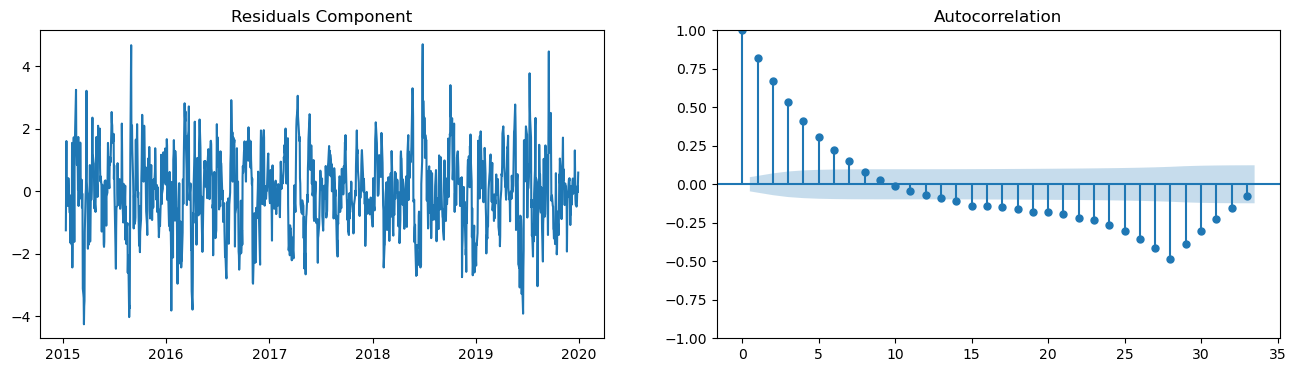

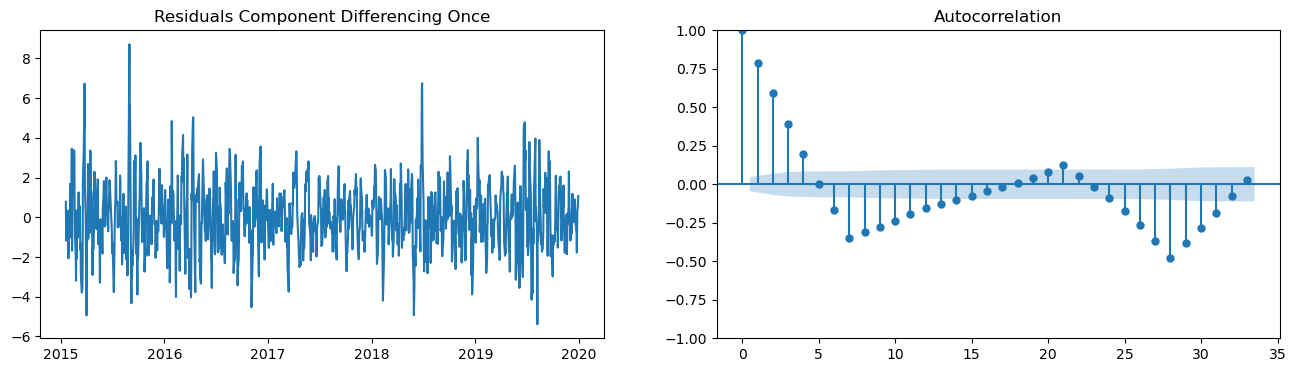

In [2]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ----------------------------------------------------
# Preprocesses the target variables (y variables) (WTI crude oil spot prices)

# Loads the daily WTI crude oil spot prices from the a .csv file (2015 until 2019) (a 5 years period) 
priceData = pd.read_csv('Crude Oil WTI Spot Price (5 Years).csv') 
# Shape [1254, 2] # The 'Date' and 'Price' columns

# Transforms the 'Date' column into executable format (for filling the missing values)
priceData['Date'] = pd.to_datetime(priceData['Date'], format='%d-%b-%y')
# Transforms the 'Date' column into the index for the dataframe
priceData.set_index('Date', inplace=True) # Shape [1254, 1]

# Fills and handles the missing values (holidays on business days and weekends)
allDates = pd.date_range(start=priceData.index.min(), end=priceData.index.max(), freq='D') # 'D' means all avilable days
priceData = priceData.reindex(allDates)
priceData.index.name = 'Date'
# Fills missing values using interpolation method
priceData['Price'] = priceData['Price'].interpolate(method='linear').round(2) # Shape [1825, 1]
# The day of the date starts from Monday and ends on Friday (1825 days + 2 days = 1827 / 7 = 261 weeks)

# Removes the last 5 rows because of the incompleteness (no saturday and sunday on that week)
priceData = priceData.iloc[:-5, :] # Shape [1820, 1]

# Defines a function to visualize the daily crude oil spot prices (original and decomposition components)
# These functions are for visualization purpose only
def visualizePriceDecomposition(priceData):
    plt.figure(figsize=(12, 8))
    # All components (original daily crude oil spot prices) (additive methodology)
    plt.subplot(4, 1, 1)
    plt.plot(priceData['Price'], label='Original Prices')
    plt.title('Original Prices', fontsize=10)
    plt.legend()
    # Trend component
    plt.subplot(4, 1, 2)
    plt.plot(priceData['trend'], label='Trend')
    plt.title('Trend Component', fontsize=10)
    plt.legend()
    # Seasonal component
    plt.subplot(4, 1, 3)
    plt.plot(priceData['seasonal'], label='Seasonality')
    plt.title('Seasonal Component', fontsize=10)
    plt.legend()
    # Residuals components
    plt.subplot(4, 1, 4)
    plt.plot(priceData['residual'], label='Residuals')
    plt.title('Residual Component', fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Calls the price decomposition package (decomposing into trend, seasonal, and residual components) and rounds these components into two decimals after
stl = STL(priceData['Price'], period=28) # 28 represents the number of days in a month 
result = stl.fit()
priceData['trend'] = result.trend.round(2)
priceData['seasonal'] = result.seasonal.round(2)
priceData['residual'] = result.resid.round(2)

# Calls the visualization function
# visualizePriceDecomposition(priceData) # Shape [1820, 4] # the 'Price', 'trend', 'seasonal, 'residual' columns

# ----------------------------------------------------

# ----------------------------------------------------
# Stationary test for the y variables (target variables)

# Defines a function to performs the Augmented Dickey-Fuller (ADF) test
def checkStationarity(timeseries, seriesName="Time Series"):
    # Performs ADF Test
    stationarityResult = adfuller(timeseries)

    # Extracts values
    adf_statistic = stationarityResult[0]
    p_value = stationarityResult[1]
    critical_values = stationarityResult[4]

    # Prints results
    print(f"\nStationarity Test for {seriesName}")
    print(f"ADF Statistic: {adf_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")

    # First Check: Stationarity based on p-value
    if p_value < 0.05:
        print("The time series is stationary (p-value < 0.05, reject H₀).")
    else:
        print("The time series is non-stationary (p-value ≥ 0.05, fail to reject H₀). Consider differencing.")

    # Second Check: ADF Statistic compared to critical values
    if adf_statistic < critical_values["1%"]:
        print("The ADF statistic confirms stationarity at the 1 percent critical value (very strong evidence).")
    elif adf_statistic < critical_values["5%"]:
        print("The ADF statistic confirms stationarity at the 5 percent critical value (moderate evidence).")
    elif adf_statistic < critical_values["10%"]:
        print("The ADF statistic confirms stationarity at the 10 percent critical value (weak evidence).")
    else:
        print("The ADF statistic does not confirm stationarity at any standard level. Differencing may be needed.")

    # Prints critical values for reference
    print("\nCritical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.4f}")
    # Prints seperator for readability
    print("\n" + "-"*50)

# Calls the function
checkStationarity(priceData['Price'], "Price") # Not Stationary
checkStationarity(priceData['trend'], "Trend") # Not Stationary
checkStationarity(priceData['seasonal'], "Seasonal") # Stationary
checkStationarity(priceData['residual'], "Residual") # Stationary

# Adds 'price_diff', 'trend_diff' columns because they are not stationary
# The _diff uses a weekly shift (7 days shifting) # Shape [1820, 6]
# Eventhough our dataset is daily, we want to make it to have a weekly behavior
priceData['price_diff'] = priceData['Price'] - priceData['Price'].shift(7)
priceData['trend_diff'] = priceData['trend'] - priceData['trend'].shift(7)

# Removes the first 7 rows because of the NaN values on the '_diff' columns
priceData = priceData.iloc[7:] # Shape [1813, 6]

# Calls the function
checkStationarity(priceData['price_diff'], "Price_Diff") # Not Stationary
checkStationarity(priceData['trend_diff'], "Trend_Diff") # Not Stationary

# Tries to conduct an ACF Test to proof the residuals is only a random variable
# Creates a new figure for residuals and its ACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.plot(priceData['residual'])
ax1.set_title("Residuals Component")
plot_acf(priceData['residual'], ax=ax2)

# Creates another figure for the differenced residuals and its ACF
priceData['residual_diff'] = priceData['residual'] - priceData['residual'].shift(7)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 4))
ax3.plot(priceData['residual_diff'])
ax3.set_title("Residuals Component Differencing Once")
plot_acf(priceData['residual_diff'].dropna(), ax=ax4)  # Drop NaN values before plotting ACF

plt.show()